In [1]:
!pip install -q google-genai
!pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm openpyxl scipy

In [2]:
import os
import json
import time
import random
import warnings

import numpy as np
import pandas as pd

from tqdm import tqdm

from google import genai

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from google.colab import userdata
from google import genai

GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")

client = genai.Client(
    api_key=GOOGLE_API_KEY
)

print("Gemini Client Loaded Successfully")

Gemini Client Loaded Successfully


In [7]:
BASE_PATH = "/content/drive/MyDrive/ABSA"

course_df = pd.read_csv(
    f"{BASE_PATH}/course_balanced.csv"
)

teacher_df = pd.read_csv(
    f"{BASE_PATH}/teacher_balanced.csv"
)

university_df = pd.read_csv(
    f"{BASE_PATH}/university_balanced.csv"
)

print("=" * 50)
print("BALANCED DATASETS LOADED")
print("=" * 50)

print("Course Dataset Shape     :", course_df.shape)
print("Teacher Dataset Shape    :", teacher_df.shape)
print("University Dataset Shape :", university_df.shape)

BALANCED DATASETS LOADED
Course Dataset Shape     : (4218, 4)
Teacher Dataset Shape    : (4218, 4)
University Dataset Shape : (4218, 4)


In [8]:
TEST_PATH = "/content/drive/MyDrive/ABSA/test_sets"

course_test = pd.read_csv(
    f"{TEST_PATH}/course_test.csv"
)

teacher_test = pd.read_csv(
    f"{TEST_PATH}/teacher_test.csv"
)

university_test = pd.read_csv(
    f"{TEST_PATH}/university_test.csv"
)

print("=" * 50)
print("TEST SETS LOADED")
print("=" * 50)

print("Course Test Shape     :", course_test.shape)
print("Teacher Test Shape    :", teacher_test.shape)
print("University Test Shape :", university_test.shape)

TEST SETS LOADED
Course Test Shape     : (844, 7)
Teacher Test Shape    : (844, 7)
University Test Shape : (844, 7)


In [9]:
print("Course Test Columns:")
print(course_test.columns.tolist())

print("\nTeacher Test Columns:")
print(teacher_test.columns.tolist())

print("\nUniversity Test Columns:")
print(university_test.columns.tolist())

Course Test Columns:
['review', 'aspect', 'sentiment', 'domain', 'row_id', 'input_text', 'label']

Teacher Test Columns:
['review', 'aspect', 'sentiment', 'domain', 'row_id', 'input_text', 'label']

University Test Columns:
['review', 'aspect', 'sentiment', 'domain', 'row_id', 'input_text', 'label']


In [10]:
label_map = {
    "positive": "positive",
    "negative": "negative",
    "neutral": "neutral"
}

all_dfs = [
    course_df,
    teacher_df,
    university_df,
    course_test,
    teacher_test,
    university_test
]

for df in all_dfs:

    df["sentiment"] = (
        df["sentiment"]
        .astype(str)
        .str.lower()
        .str.strip()
        .map(label_map)
    )

    df.dropna(
        subset=["sentiment"],
        inplace=True
    )

print("Labels cleaned successfully.")

Labels cleaned successfully.


In [11]:
multidomain_df = pd.concat([
    course_df,
    teacher_df,
    university_df
]).reset_index(drop=True)

print("=" * 50)
print("MULTIDOMAIN DATASET")
print("=" * 50)

print("Shape:", multidomain_df.shape)

multidomain_df.head()

MULTIDOMAIN DATASET
Shape: (12654, 4)


,review,aspect,sentiment,domain
0,"This course was amazing. For the first time, t...",course,positive,course
1,"This course was amazing. For the first time, t...",lab partner,positive,course
2,"Extremely boring and lectures were useless, bu...",lectures,negative,course
3,"Extremely boring and lectures were useless, bu...",information taught,positive,course
4,"Cool course content, requires effort to get it...",course content,positive,course


In [12]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    multidomain_df,
    test_size=0.10,
    stratify=multidomain_df["sentiment"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("=" * 50)
print("MULTIDOMAIN SPLIT")
print("=" * 50)

print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)

MULTIDOMAIN SPLIT
Train Shape      : (11388, 4)
Validation Shape : (1266, 4)


domain
course        4218
teacher       4218
university    4218
Name: count, dtype: int64


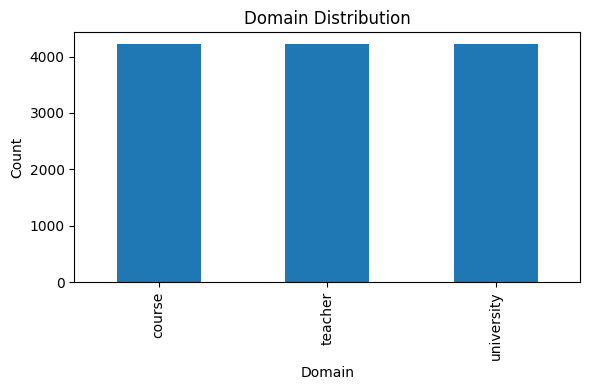

In [13]:
domain_counts = multidomain_df["domain"].value_counts()

print(domain_counts)

plt.figure(figsize=(6,4))

domain_counts.plot(
    kind="bar"
)

plt.title("Domain Distribution")
plt.xlabel("Domain")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

sentiment
positive    7764
negative    3550
neutral     1340
Name: count, dtype: int64


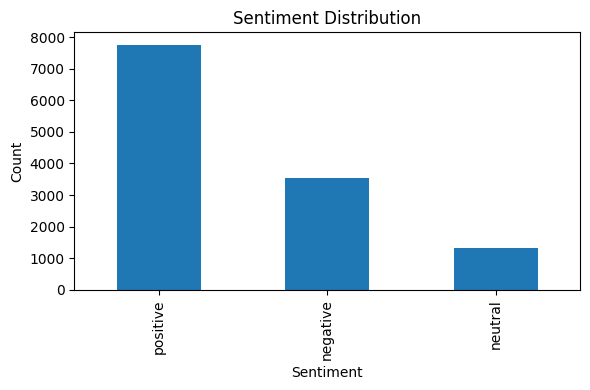

In [14]:
sentiment_counts = multidomain_df["sentiment"].value_counts()

print(sentiment_counts)

plt.figure(figsize=(6,4))

sentiment_counts.plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

sentiment   negative  neutral  positive
domain                                 
course          1456      723      2039
teacher         1437      436      2345
university       657      181      3380


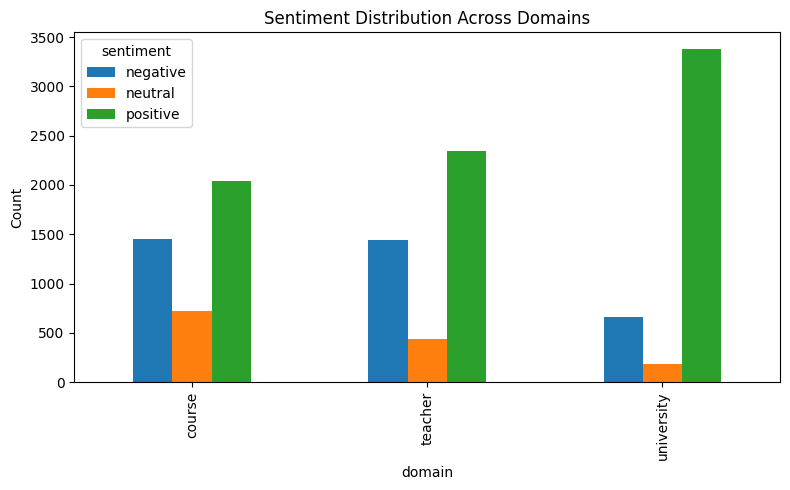

In [15]:
domain_sentiment = pd.crosstab(
    multidomain_df["domain"],
    multidomain_df["sentiment"]
)

print(domain_sentiment)

domain_sentiment.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Sentiment Distribution Across Domains"
)

plt.ylabel("Count")

plt.tight_layout()
plt.show()

count    12654.00000
mean       304.87419
std        299.72918
min         10.00000
25%        124.00000
50%        233.00000
75%        347.00000
max       2513.00000
Name: review_length, dtype: float64


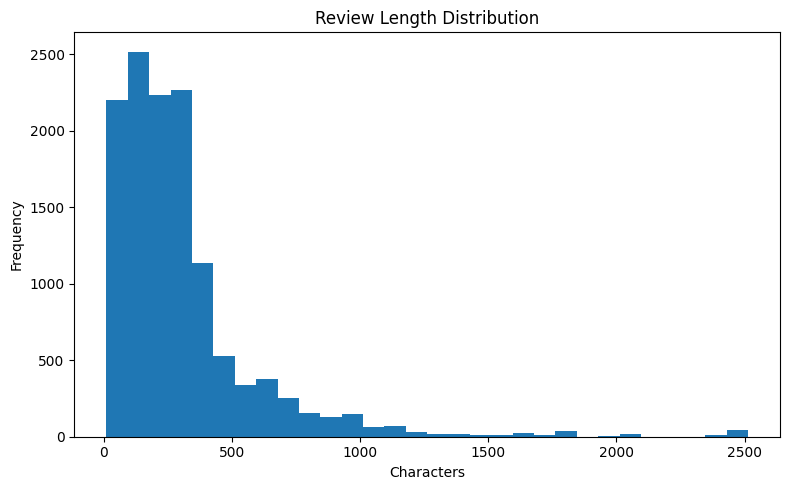

In [16]:
multidomain_df["review_length"] = (
    multidomain_df["review"]
    .astype(str)
    .apply(len)
)

print(
    multidomain_df["review_length"]
    .describe()
)

plt.figure(figsize=(8,5))

plt.hist(
    multidomain_df["review_length"],
    bins=30
)

plt.title(
    "Review Length Distribution"
)

plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [17]:
review_stats = multidomain_df.groupby(
    "domain"
)["review_length"].describe()

display(review_stats)

,count,mean,std,min,25%,50%,75%,max
domain,,,,,,,,
course,4218.0,283.835941,229.851541,10.0,126.0,224.0,360.0,1788.0
teacher,4218.0,357.178521,297.990653,11.0,208.0,310.0,349.0,2392.0
university,4218.0,273.608108,351.807173,30.0,78.0,153.5,297.0,2513.0


,count
aspect,
course,871
this course,221
class,145
assignments,142
content,138
material,68
lectures,60
concepts,52
midterm,52


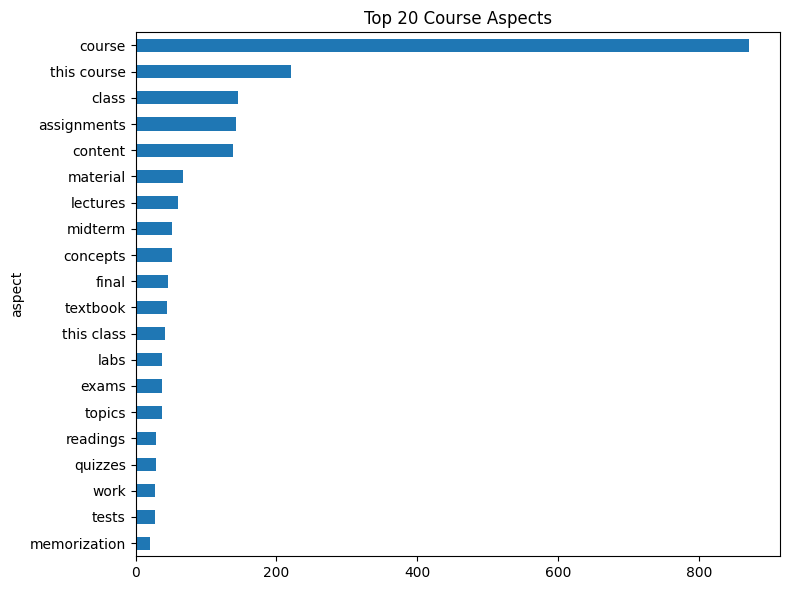

In [18]:
course_aspects = (
    course_df["aspect"]
    .value_counts()
    .head(20)
)

display(course_aspects)

plt.figure(figsize=(8,6))

course_aspects.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 Course Aspects"
)

plt.tight_layout()
plt.show()

,count
aspect,
class,271
professor,257
teacher,245
course,225
this class,120
prof,81
this course,79
tests,59
assignments,55


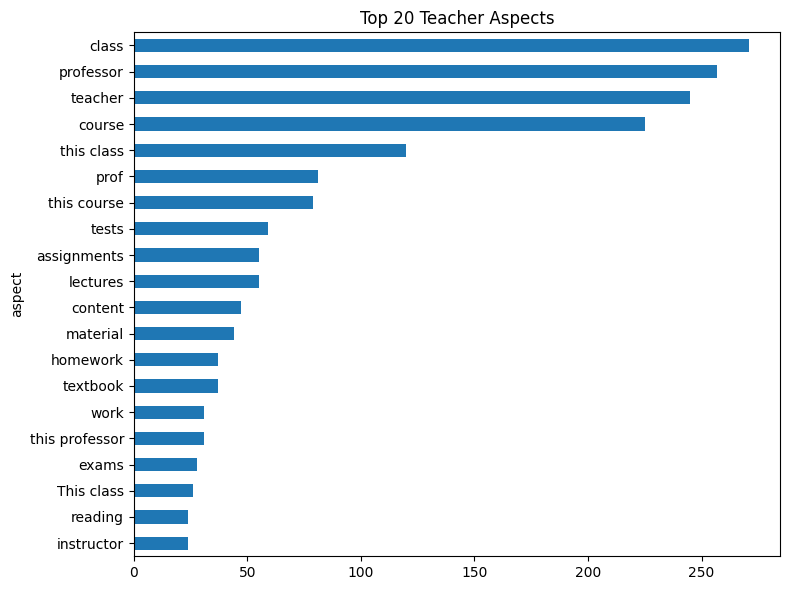

In [19]:
teacher_aspects = (
    teacher_df["aspect"]
    .value_counts()
    .head(20)
)

display(teacher_aspects)

plt.figure(figsize=(8,6))

teacher_aspects.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 Teacher Aspects"
)

plt.tight_layout()
plt.show()

,count
aspect,
campus,403
university,337
facilities,218
uni,153
societies,127
staff,95
lecturers,83
people,54
course,51


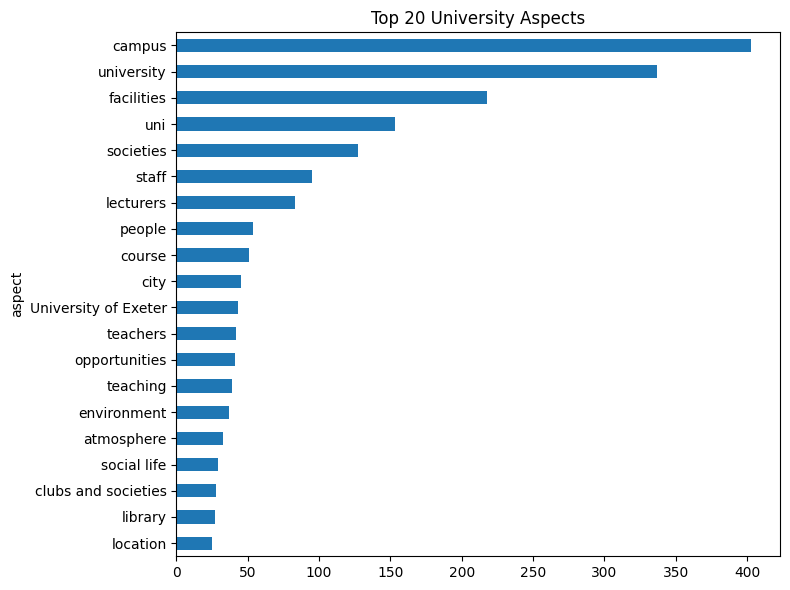

In [20]:
university_aspects = (
    university_df["aspect"]
    .value_counts()
    .head(20)
)

display(university_aspects)

plt.figure(figsize=(8,6))

university_aspects.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 University Aspects"
)

plt.tight_layout()
plt.show()

In [21]:
sentiment_percent = pd.crosstab(
    multidomain_df["domain"],
    multidomain_df["sentiment"],
    normalize="index"
) * 100

display(
    sentiment_percent.round(2)
)

sentiment,negative,neutral,positive
domain,,,
course,34.52,17.14,48.34
teacher,34.07,10.34,55.60
university,15.58,4.29,80.13


In [22]:
summary = pd.DataFrame({

    "Domain": [
        "Course",
        "Teacher",
        "University"
    ],

    "Samples": [
        len(course_df),
        len(teacher_df),
        len(university_df)
    ],

    "Unique Aspects": [
        course_df["aspect"].nunique(),
        teacher_df["aspect"].nunique(),
        university_df["aspect"].nunique()
    ]
})

display(summary)

,Domain,Samples,Unique Aspects
0,Course,4218,1485
1,Teacher,4218,1697
2,University,4218,503


In [23]:
MODEL_NAME = "gemini-2.5-flash"

print("Model:", MODEL_NAME)

Model: gemini-2.5-flash


In [24]:
response = client.models.generate_content(
    model=MODEL_NAME,
    contents="Say hello"
)

print(response.text)

Hello!


In [25]:
ZERO_SHOT_PROMPT = """
You are an expert Aspect-Based Sentiment Analysis system.

Determine the sentiment expressed towards the given aspect.

Possible labels:
positive
negative
neutral

Review:
{review}

Aspect:
{aspect}

Output ONLY one label:
positive
negative
neutral
"""

print(ZERO_SHOT_PROMPT)


You are an expert Aspect-Based Sentiment Analysis system.

Determine the sentiment expressed towards the given aspect.

Possible labels:
positive
negative
neutral

Review:
{review}

Aspect:
{aspect}

Output ONLY one label:
positive
negative
neutral



In [26]:
import time

def predict_sentiment(review, aspect):

    prompt = ZERO_SHOT_PROMPT.format(
        review=review,
        aspect=aspect
    )

    prediction = None

    for attempt in range(5):

        try:

            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt
            )

            prediction = (
                response.text
                .strip()
                .lower()
            )

            break

        except Exception as e:

            print(
                f"Attempt {attempt+1}/5 failed: {e}"
            )

            time.sleep(5)

    if prediction is None:
        return "neutral"

    if "positive" in prediction:
        return "positive"

    if "negative" in prediction:
        return "negative"

    if "neutral" in prediction:
        return "neutral"

    return "neutral"

In [29]:
sample = course_test.iloc[0]

pred = predict_sentiment(
    sample["review"],
    sample["aspect"]
)

print("Aspect:")
print(sample["aspect"])

print("\nTrue Label:")
print(sample["sentiment"])

print("\nPredicted Label:")
print(pred)

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...
Aspect:
programming language

True Label:
negative

Predicted Label:
negative


In [30]:
print("Course Test Shape     :", course_test.shape)
print("Teacher Test Shape    :", teacher_test.shape)
print("University Test Shape :", university_test.shape)

print("\nCourse Test Sample")
display(course_test.head())

Course Test Shape     : (844, 7)
Teacher Test Shape    : (844, 7)
University Test Shape : (844, 7)

Course Test Sample


,review,aspect,sentiment,domain,row_id,input_text,label
0,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,course,course_188,[DOMAIN] course [ASPECT] programming language ...,0
1,This class is literally just epsilon and delta...,mobius quizzes,negative,course,course_3409,[DOMAIN] course [ASPECT] mobius quizzes [TEXT]...,0
2,Overall content heavy and quite a tricky cours...,course,negative,course,course_254,[DOMAIN] course [ASPECT] course [TEXT] Overall...,0
3,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,course,course_1797,[DOMAIN] course [ASPECT] Professor Sneed class...,2
4,Despite many ppl complaining about the Mobius ...,desmos,positive,course,course_3891,[DOMAIN] course [ASPECT] desmos [TEXT] Despite...,2


In [31]:
from tqdm import tqdm
import pandas as pd
import os
import time

def run_gemini_zero_shot(
    test_df,
    experiment_name,
    save_every=25
):

    os.makedirs(
        experiment_name,
        exist_ok=True
    )

    predictions = []

    for idx in tqdm(range(len(test_df))):

        row = test_df.iloc[idx]

        pred = predict_sentiment(
            str(row["review"]),
            str(row["aspect"])
        )

        predictions.append({

            "row_id": row["row_id"],

            "review": row["review"],

            "aspect": row["aspect"],

            "true_sentiment":
                row["sentiment"],

            "predicted_sentiment":
                pred

        })

        if (
            (idx + 1) % save_every == 0
            or idx == len(test_df) - 1
        ):

            checkpoint_df = pd.DataFrame(
                predictions
            )

            checkpoint_df.to_csv(
                f"{experiment_name}/predictions_checkpoint.csv",
                index=False
            )

        time.sleep(1.5)

    predictions_df = pd.DataFrame(
        predictions
    )

    predictions_df.to_csv(
        f"{experiment_name}/predictions.csv",
        index=False
    )

    return predictions_df

In [32]:
course_predictions = run_gemini_zero_shot(
    course_test,
    "gemini_multidomain_zero_shot_course"
)

  0%|          | 1/844 [00:03<49:59,  3.56s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...


  4%|▍         | 33/844 [02:23<54:44,  4.05s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...
Attempt 2/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 10 seconds...


  4%|▍         | 34/844 [02:47<2:14:24,  9.96s/it]

...

 99%|█████████▉| 839/844 [1:07:42<00:22,  4.41s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...


100%|█████████▉| 840/844 [1:07:52<00:24,  6.24s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...


100%|██████████| 844/844 [1:08:16<00:00,  4.85s/it]


In [33]:
course_predictions.shape

(844, 5)

In [34]:
course_predictions.head()

,row_id,review,aspect,true_sentiment,predicted_sentiment
0,course_188,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,negative
1,course_3409,This class is literally just epsilon and delta...,mobius quizzes,negative,negative
2,course_254,Overall content heavy and quite a tricky cours...,course,negative,positive
3,course_1797,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,neutral
4,course_3891,Despite many ppl complaining about the Mobius ...,desmos,positive,positive


In [35]:
# COURSE METRICS

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

y_true = course_predictions["true_sentiment"]
y_pred = course_predictions["predicted_sentiment"]

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("=" * 50)
print("COURSE RESULTS")
print("=" * 50)

print("Accuracy     :", round(accuracy, 4))
print("Macro F1     :", round(macro_f1, 4))
print("Weighted F1  :", round(weighted_f1, 4))

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

COURSE RESULTS
Accuracy     : 0.7832
Macro F1     : 0.646
Weighted F1  : 0.7462

Classification Report

              precision    recall  f1-score   support

    negative       0.75      0.89      0.82       291
     neutral       0.57      0.16      0.25       145
    positive       0.83      0.93      0.87       408

    accuracy                           0.78       844
   macro avg       0.72      0.66      0.65       844
weighted avg       0.76      0.78      0.75       844



In [36]:
metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro_F1",
        "Weighted_F1"
    ],

    "Score": [
        accuracy,
        macro_f1,
        weighted_f1
    ]
})

metrics_df.to_csv(
    "gemini_multidomain_zero_shot_course_metrics.csv",
    index=False
)

metrics_df

,Metric,Score
0,Accuracy,0.783175
1,Macro_F1,0.645985
2,Weighted_F1,0.746186


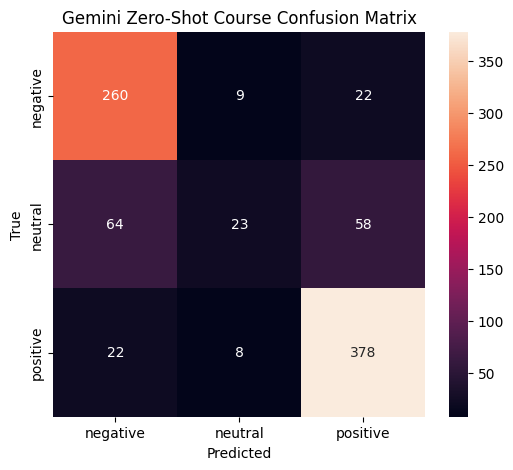

In [37]:
# COURSE CONFUSION MATRIX


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "negative",
        "neutral",
        "positive"
    ],
    yticklabels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.title(
    "Gemini Zero-Shot Course Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "True"
)

plt.show()

In [38]:
errors_df = course_predictions[
    course_predictions["true_sentiment"]
    !=
    course_predictions["predicted_sentiment"]
]

print("Total Errors:", len(errors_df))

errors_df.to_csv(
    "gemini_multidomain_zero_shot_course_errors.csv",
    index=False
)

errors_df.head()

Total Errors: 183


,row_id,review,aspect,true_sentiment,predicted_sentiment
2,course_254,Overall content heavy and quite a tricky cours...,course,negative,positive
3,course_1797,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,neutral
7,course_3604,Very interesting course! You cover a wide rang...,material,neutral,positive
15,course_1782,"Really difficult course. Tons of readings, ton...",theory,neutral,negative
19,course_162,Birdiest course I've ever taken. Don't even ne...,version of the textbook,neutral,positive


In [39]:
neutral_errors = course_predictions[
    course_predictions["true_sentiment"]
    == "neutral"
]

neutral_errors = neutral_errors[
    neutral_errors["predicted_sentiment"]
    != "neutral"
]

print(
    "Neutral Errors:",
    len(neutral_errors)
)

neutral_errors.to_csv(
    "gemini_multidomain_zero_shot_course_neutral_errors.csv",
    index=False
)

neutral_errors.head()

Neutral Errors: 122


,row_id,review,aspect,true_sentiment,predicted_sentiment
7,course_3604,Very interesting course! You cover a wide rang...,material,neutral,positive
15,course_1782,"Really difficult course. Tons of readings, ton...",theory,neutral,negative
19,course_162,Birdiest course I've ever taken. Don't even ne...,version of the textbook,neutral,positive
21,course_209,some memorization required for the midterm,midterm,neutral,negative
27,course_3755,Don't take it if you have the option not to. I...,final,neutral,negative


## Gemini Zero-Shot Results (Course Domain)

The Gemini 2.5 Flash model was evaluated using a zero-shot prompting strategy on the Course domain test set consisting of 844 aspect-level instances. The model achieved an overall accuracy of **78.32%**, a macro F1-score of **0.6460**, and a weighted F1-score of **0.7462**.

### Overall Performance

| Metric | Score |
|----------|----------|
| Accuracy | 0.7832 |
| Macro F1 | 0.6460 |
| Weighted F1 | 0.7462 |

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|---------|---------|---------|---------|---------|
| Negative | 0.75 | 0.89 | 0.82 | 291 |
| Neutral | 0.57 | 0.16 | 0.25 | 145 |
| Positive | 0.83 | 0.93 | 0.87 | 408 |
| **Accuracy** | - | - | **0.78** | **844** |
| **Macro Average** | **0.72** | **0.66** | **0.65** | **844** |
| **Weighted Average** | **0.76** | **0.78** | **0.75** | **844** |

### Confusion Matrix Analysis

The confusion matrix revealed that Gemini performed strongly on positive and negative sentiment classification but struggled substantially with neutral sentiment detection.

- **Negative sentiment:** 260 of 291 instances were correctly classified, resulting in a recall of **0.89**.
- **Positive sentiment:** 378 of 408 instances were correctly classified, resulting in a recall of **0.93**.
- **Neutral sentiment:** Only 23 of 145 instances were correctly classified, resulting in a recall of **0.16**.

A large proportion of neutral instances were incorrectly assigned a sentiment polarity:

- Neutral → Negative: 64 instances
- Neutral → Positive: 58 instances
- Neutral → Neutral: 23 instances

This indicates that Gemini frequently inferred sentiment polarity even when the aspect-related statement was largely factual, balanced, or sentiment-neutral.

### Error Analysis

A total of **183 misclassifications** were identified within the Course domain test set.

| Category | Count |
|-----------|--------|
| Total Errors | 183 |
| Neutral Errors | 122 |

Neutral sentiment contributed disproportionately to overall errors, accounting for approximately **66.7%** of all misclassified instances.

Examples of neutral misclassifications include:

| Row ID | True Label | Predicted Label |
|---------|------------|----------------|
| course_3604 | Neutral | Positive |
| course_1782 | Neutral | Negative |
| course_162 | Neutral | Positive |
| course_209 | Neutral | Negative |
| course_3755 | Neutral | Negative |

### Discussion

The results demonstrate that Gemini is highly effective at identifying explicit positive and negative opinions. However, the model exhibits a strong tendency to force sentiment polarity when encountering neutral statements. This behaviour is reflected by the low neutral recall score of **0.16**, which substantially reduced overall macro F1 performance.

The findings suggest that although zero-shot prompting enables strong sentiment recognition for polarised opinions, additional prompt guidance may be required to improve neutral sentiment detection. Consequently, a few-shot prompting strategy will be investigated in the next experiment to determine whether providing representative multidomain examples can improve sentiment boundary recognition, particularly for the underrepresented neutral class.

### Key Finding

The primary limitation of Gemini Zero-Shot prompting in the Course domain is its inability to reliably identify neutral sentiment. While positive and negative classifications achieve high recall values (0.93 and 0.89 respectively), neutral recall remains extremely low (0.16), indicating that the model frequently interprets factual or balanced statements as sentiment-bearing opinions. This motivates the use of multidomain few-shot prompting in subsequent experiments.

In [40]:
positive_examples = (
    train_df[
        train_df["sentiment"] == "positive"
    ]
    .sample(
        3,
        random_state=42
    )
)

negative_examples = (
    train_df[
        train_df["sentiment"] == "negative"
    ]
    .sample(
        3,
        random_state=42
    )
)

neutral_examples = (
    train_df[
        train_df["sentiment"] == "neutral"
    ]
    .sample(
        3,
        random_state=42
    )
)

few_shot_examples = pd.concat([
    positive_examples,
    negative_examples,
    neutral_examples
]).reset_index(drop=True)

few_shot_examples[
    ["review","aspect","sentiment","domain"]
]

,review,aspect,sentiment,domain
0,A good course of review and some new content f...,Course notes,positive,course
1,Exeter is one of a good universities that come...,experts,positive,university
2,"living and studying in exeter is good, everyth...",everything you found here,positive,university
3,This is definitely a course filled with inform...,syllabus,negative,teacher
4,THIS CLASS IS TERRIBLE! I LEAVE EACH SESSION F...,EACH SESSION,negative,teacher
5,I do not recommend this class for the summer. ...,test,negative,teacher
6,I have taken four classes with this professor....,text book,neutral,teacher
7,The class was not difficult just the professor...,class,neutral,teacher
8,Great teacher. He's very helpful when you don'...,the class,neutral,teacher


In [41]:
few_shot_prompt = ""

for _, row in few_shot_examples.iterrows():

    few_shot_prompt += f"""
Review: {row['review']}

Aspect: {row['aspect']}

Answer: {row['sentiment']}

"""

print(few_shot_prompt[:3000])


Review: A good course of review and some new content for students that took 4U Chemistry in high school. Course notes are very useful and the course is well designed.

Aspect: Course notes

Answer: positive


Review: Exeter is one of a good universities that come with good location and nature. There a lot of experts, good professors and staffs who always support the learners

Aspect: experts

Answer: positive


Review: living and studying in exeter is good, everything you found here will be a joy to your life

Aspect: everything you found here

Answer: positive


Review: This is definitely a course filled with information that should be taught to all students even before they enter university. Looking back at Canada's colonial past and really understanding the racist roots was eye-opening. The course was divided into 8 quizzes( best 6/8 for final mark), a 40% final and 40% group project. The course material was good just the prof was completely unorganized. Lecture material was just d

In [42]:
FEW_SHOT_PROMPT = f"""
You are an expert Aspect-Based Sentiment Analysis system.

Determine the sentiment expressed towards the specified aspect.

Possible labels:

positive
negative
neutral

Examples:

{few_shot_prompt}

Now classify the following example.

Review:
{{review}}

Aspect:
{{aspect}}

Respond with exactly one word.

Answer:
"""

print(
    FEW_SHOT_PROMPT[:5000]
)


You are an expert Aspect-Based Sentiment Analysis system.

Determine the sentiment expressed towards the specified aspect.

Possible labels:

positive
negative
neutral

Examples:


Review: A good course of review and some new content for students that took 4U Chemistry in high school. Course notes are very useful and the course is well designed.

Aspect: Course notes

Answer: positive


Review: Exeter is one of a good universities that come with good location and nature. There a lot of experts, good professors and staffs who always support the learners

Aspect: experts

Answer: positive


Review: living and studying in exeter is good, everything you found here will be a joy to your life

Aspect: everything you found here

Answer: positive


Review: This is definitely a course filled with information that should be taught to all students even before they enter university. Looking back at Canada's colonial past and really understanding the racist roots was eye-opening. The course was di

In [43]:
def predict_sentiment_few_shot(
    review,
    aspect
):

    prompt = FEW_SHOT_PROMPT.format(
        review=review,
        aspect=aspect
    )

    max_attempts = 8

    for attempt in range(max_attempts):

        try:

            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt
            )

            prediction = (
                response.text
                .strip()
                .lower()
            )

            if "positive" in prediction:
                return "positive"

            if "negative" in prediction:
                return "negative"

            if "neutral" in prediction:
                return "neutral"

            return "neutral"

        except Exception as e:

            wait_time = min(
                5 * (attempt + 1),
                30
            )

            print(
                f"Attempt {attempt+1}/{max_attempts} failed: {e}"
            )

            time.sleep(wait_time)

    return "neutral"

In [44]:
sample = course_test.iloc[0]

pred = predict_sentiment_few_shot(
    sample["review"],
    sample["aspect"]
)

print("Aspect:")
print(sample["aspect"])

print("\nTrue:")
print(sample["sentiment"])

print("\nPredicted:")
print(pred)

Aspect:
programming language

True:
negative

Predicted:
negative


In [45]:
# FULL FEW-SHOT EVALUATION


from tqdm import tqdm
import pandas as pd
import os
import time

def run_gemini_few_shot(
    test_df,
    experiment_name,
    save_every=25
):

    os.makedirs(
        experiment_name,
        exist_ok=True
    )

    predictions = []

    for idx in tqdm(range(len(test_df))):

        row = test_df.iloc[idx]

        pred = predict_sentiment_few_shot(
            str(row["review"]),
            str(row["aspect"])
        )

        predictions.append({

            "row_id": row["row_id"],
            "review": row["review"],
            "aspect": row["aspect"],
            "true_sentiment": row["sentiment"],
            "predicted_sentiment": pred

        })

        if (
            (idx + 1) % save_every == 0
            or idx == len(test_df) - 1
        ):

            pd.DataFrame(
                predictions
            ).to_csv(
                f"{experiment_name}/predictions_checkpoint.csv",
                index=False
            )

        time.sleep(1.5)

    predictions_df = pd.DataFrame(
        predictions
    )

    predictions_df.to_csv(
        f"{experiment_name}/predictions.csv",
        index=False
    )

    return predictions_df

In [46]:
course_few_shot_predictions = run_gemini_few_shot(
    course_test,
    "gemini_multidomain_few_shot_course"
)

  2%|▏         | 16/844 [01:02<53:30,  3.88s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


  4%|▍         | 32/844 [02:19<1:11:00,  5.25s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


  4%|▍         | 33/844 [02:33<1:46:32,  7.88s/it]

...

 63%|██████▎   | 533/844 [46:03<21:00,  4.05s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


 72%|███████▏  | 606/844 [50:58<16:46,  4.23s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


100%|██████████| 844/844 [1:07:44<00:00,  4.82s/it]


In [47]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

y_true = course_few_shot_predictions[
    "true_sentiment"
]

y_pred = course_few_shot_predictions[
    "predicted_sentiment"
]

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("=" * 50)
print("COURSE FEW-SHOT RESULTS")
print("=" * 50)

print("Accuracy     :", round(accuracy,4))
print("Macro F1     :", round(macro_f1,4))
print("Weighted F1  :", round(weighted_f1,4))

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

COURSE FEW-SHOT RESULTS
Accuracy     : 0.795
Macro F1     : 0.6895
Weighted F1  : 0.7718

Classification Report

              precision    recall  f1-score   support

    negative       0.78      0.89      0.83       291
     neutral       0.58      0.26      0.36       145
    positive       0.84      0.91      0.87       408

    accuracy                           0.80       844
   macro avg       0.73      0.69      0.69       844
weighted avg       0.77      0.80      0.77       844



In [48]:
teacher_few_shot_predictions = run_gemini_few_shot(
    teacher_test,
    "gemini_multidomain_few_shot_teacher"
)

 11%|█▏        | 96/844 [06:35<51:36,  4.14s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


 15%|█▌        | 128/844 [09:03<46:51,  3.93s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


 27%|██▋       | 227/844 [15:46<36:22,  3.54s/it]

...

 86%|████████▌ | 724/844 [52:03<08:50,  4.42s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


 99%|█████████▉| 839/844 [59:54<00:19,  3.92s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


100%|██████████| 844/844 [1:00:21<00:00,  4.29s/it]


TEACHER FEW-SHOT RESULTS
Accuracy     : 0.8531
Macro F1     : 0.6996
Weighted F1  : 0.8376

Classification Report

              precision    recall  f1-score   support

    negative       0.84      0.92      0.88       288
     neutral       0.48      0.23      0.31        87
    positive       0.89      0.93      0.91       469

    accuracy                           0.85       844
   macro avg       0.74      0.69      0.70       844
weighted avg       0.83      0.85      0.84       844


Metrics Saved Successfully


,Metric,Score
0,Accuracy,0.853081
1,Macro_F1,0.699614
2,Weighted_F1,0.837551


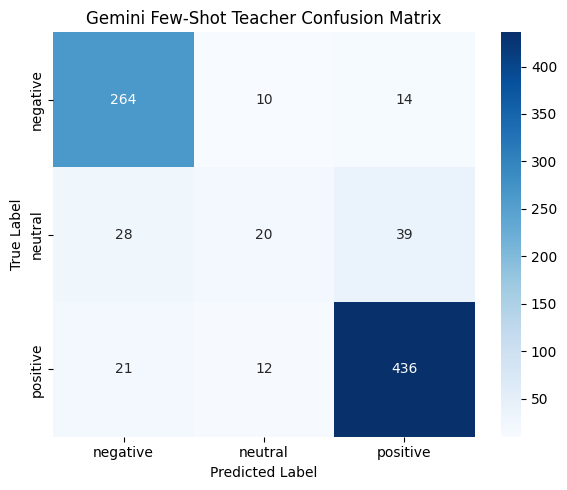


Total Errors: 124


,row_id,review,aspect,true_sentiment,predicted_sentiment
3,teacher_1051,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,positive
11,teacher_190,"Just like a typical analog course, started fro...",Prof. Levine,positive,neutral
38,teacher_2043,Ms. Gray is nice. Seems new to teaching. She d...,Class format,neutral,negative
43,teacher_425,I am a first year biology student who took thi...,laboratory component,neutral,positive
48,teacher_2477,"He teaches okay, but totally screws you over o...",This professor,neutral,negative



Neutral Errors: 67


,row_id,review,aspect,true_sentiment,predicted_sentiment
3,teacher_1051,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,positive
38,teacher_2043,Ms. Gray is nice. Seems new to teaching. She d...,Class format,neutral,negative
43,teacher_425,I am a first year biology student who took thi...,laboratory component,neutral,positive
48,teacher_2477,"He teaches okay, but totally screws you over o...",This professor,neutral,negative
56,teacher_23,Really easy class! I definitely recommend it! ...,assignments,neutral,positive


In [49]:
# =====================================================
# TEACHER FEW-SHOT METRICS
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# True and predicted labels
y_true = teacher_few_shot_predictions[
    "true_sentiment"
]

y_pred = teacher_few_shot_predictions[
    "predicted_sentiment"
]

# Metrics
accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

# Print Results
print("=" * 50)
print("TEACHER FEW-SHOT RESULTS")
print("=" * 50)

print("Accuracy     :", round(accuracy, 4))
print("Macro F1     :", round(macro_f1, 4))
print("Weighted F1  :", round(weighted_f1, 4))

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

# Save Metrics
metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro_F1",
        "Weighted_F1"
    ],

    "Score": [
        accuracy,
        macro_f1,
        weighted_f1
    ]
})

metrics_df.to_csv(
    "gemini_multidomain_few_shot_teacher_metrics.csv",
    index=False
)

print("\nMetrics Saved Successfully")

display(metrics_df)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "negative",
        "neutral",
        "positive"
    ],
    yticklabels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.title(
    "Gemini Few-Shot Teacher Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.tight_layout()
plt.show()

# =====================================================
# ERROR ANALYSIS
# =====================================================

errors_df = teacher_few_shot_predictions[
    teacher_few_shot_predictions["true_sentiment"]
    !=
    teacher_few_shot_predictions["predicted_sentiment"]
]

print("\nTotal Errors:", len(errors_df))

errors_df.to_csv(
    "gemini_multidomain_few_shot_teacher_errors.csv",
    index=False
)

display(errors_df.head())

# =====================================================
# NEUTRAL ERROR ANALYSIS
# =====================================================

neutral_errors = teacher_few_shot_predictions[
    teacher_few_shot_predictions["true_sentiment"]
    == "neutral"
]

neutral_errors = neutral_errors[
    neutral_errors["predicted_sentiment"]
    != "neutral"
]

print(
    "\nNeutral Errors:",
    len(neutral_errors)
)

neutral_errors.to_csv(
    "gemini_multidomain_few_shot_teacher_neutral_errors.csv",
    index=False
)

display(neutral_errors.head())

In [50]:
university_few_shot_predictions = run_gemini_few_shot(
    university_test,
    "gemini_multidomain_few_shot_university"
)

 51%|█████     | 427/844 [26:07<22:46,  3.28s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


 51%|█████     | 428/844 [26:18<36:53,  5.32s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


 52%|█████▏    | 441/844 [27:06<19:47,  2.95s/it]

...

 57%|█████▋    | 482/844 [30:30<23:06,  3.83s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


 58%|█████▊    | 489/844 [31:00<22:28,  3.80s/it]

Attempt 1/8 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


100%|██████████| 844/844 [51:46<00:00,  3.68s/it]


UNIVERSITY FEW-SHOT RESULTS
Accuracy     : 0.9455
Macro F1     : 0.7217
Weighted F1  : 0.9382

Classification Report

              precision    recall  f1-score   support

    negative       0.84      0.91      0.87       132
     neutral       0.50      0.22      0.31        36
    positive       0.98      0.99      0.98       676

    accuracy                           0.95       844
   macro avg       0.77      0.71      0.72       844
weighted avg       0.94      0.95      0.94       844


Metrics Saved Successfully


,Metric,Score
0,Accuracy,0.945498
1,Macro_F1,0.721663
2,Weighted_F1,0.938207


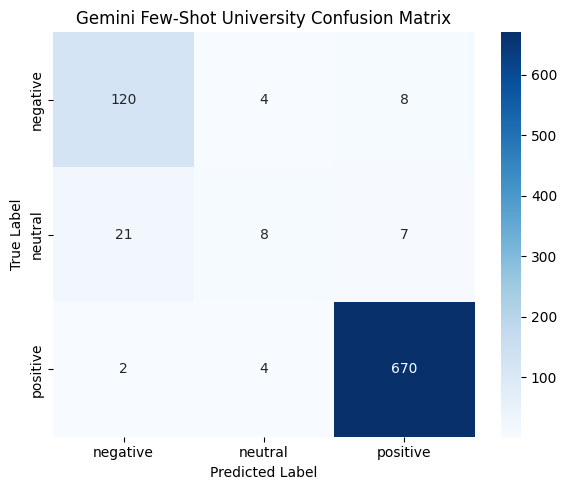


Total Errors: 46


,row_id,review,aspect,true_sentiment,predicted_sentiment
3,university_2061,It’s difficult for me to rate the aspects of t...,students union,neutral,positive
26,university_2550,"Comfort is very good, the bed is very soft, ve...",plants,positive,neutral
30,university_2606,"offers a lot of facilities, could improve it's...",internet connection,neutral,negative
37,university_355,"library is 24/7, The campus is beautiful and s...",food choices,neutral,negative
42,university_2939,A lot of pressure is put on career opportuniti...,career opportunities,neutral,negative



Neutral Errors: 28


,row_id,review,aspect,true_sentiment,predicted_sentiment
3,university_2061,It’s difficult for me to rate the aspects of t...,students union,neutral,positive
30,university_2606,"offers a lot of facilities, could improve it's...",internet connection,neutral,negative
37,university_355,"library is 24/7, The campus is beautiful and s...",food choices,neutral,negative
42,university_2939,A lot of pressure is put on career opportuniti...,career opportunities,neutral,negative
160,university_2636,Good overall. But should listen to wishes of t...,The Students Guild,neutral,negative



Classification Report Saved Successfully


In [51]:
# =====================================================
# UNIVERSITY FEW-SHOT METRICS
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# METRICS
# =====================================================

y_true = university_few_shot_predictions[
    "true_sentiment"
]

y_pred = university_few_shot_predictions[
    "predicted_sentiment"
]

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("=" * 50)
print("UNIVERSITY FEW-SHOT RESULTS")
print("=" * 50)

print("Accuracy     :", round(accuracy, 4))
print("Macro F1     :", round(macro_f1, 4))
print("Weighted F1  :", round(weighted_f1, 4))

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

# =====================================================
# SAVE METRICS
# =====================================================

metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro_F1",
        "Weighted_F1"
    ],

    "Score": [
        accuracy,
        macro_f1,
        weighted_f1
    ]
})

metrics_df.to_csv(
    "gemini_multidomain_few_shot_university_metrics.csv",
    index=False
)

print("\nMetrics Saved Successfully")

display(metrics_df)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "negative",
        "neutral",
        "positive"
    ],
    yticklabels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.title(
    "Gemini Few-Shot University Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.tight_layout()

plt.savefig(
    "gemini_multidomain_few_shot_university_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# ERROR ANALYSIS
# =====================================================

errors_df = university_few_shot_predictions[
    university_few_shot_predictions["true_sentiment"]
    !=
    university_few_shot_predictions["predicted_sentiment"]
]

print("\nTotal Errors:", len(errors_df))

errors_df.to_csv(
    "gemini_multidomain_few_shot_university_errors.csv",
    index=False
)

display(errors_df.head())

# =====================================================
# NEUTRAL ERROR ANALYSIS
# =====================================================

neutral_errors = university_few_shot_predictions[
    university_few_shot_predictions["true_sentiment"]
    == "neutral"
]

neutral_errors = neutral_errors[
    neutral_errors["predicted_sentiment"]
    != "neutral"
]

print(
    "\nNeutral Errors:",
    len(neutral_errors)
)

neutral_errors.to_csv(
    "gemini_multidomain_few_shot_university_neutral_errors.csv",
    index=False
)

display(neutral_errors.head())

# =====================================================
# CLASSIFICATION REPORT CSV
# =====================================================

report_dict = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_df.to_csv(
    "gemini_multidomain_few_shot_university_classification_report.csv"
)

print("\nClassification Report Saved Successfully")

In [56]:
teacher_predictions = run_gemini_zero_shot(
    teacher_test,
    "gemini_multidomain_zero_shot_teacher"
)

 29%|██▊       | 241/844 [15:40<43:02,  4.28s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...
Attempt 2/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 10 seconds...


 43%|████▎     | 367/844 [24:05<31:06,  3.91s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...


 49%|████▊     | 410/844 [27:00<25:45,  3.56s/it]

...

 73%|███████▎  | 615/844 [43:06<13:12,  3.46s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...


 97%|█████████▋| 821/844 [57:36<02:03,  5.36s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...


100%|██████████| 844/844 [59:18<00:00,  4.22s/it]


TEACHER ZERO-SHOT RESULTS
Accuracy     : 0.8531
Macro F1     : 0.6777
Weighted F1  : 0.8303

Classification Report

              precision    recall  f1-score   support

    negative       0.84      0.92      0.88       288
     neutral       0.50      0.16      0.24        87
    positive       0.88      0.94      0.91       469

    accuracy                           0.85       844
   macro avg       0.74      0.67      0.68       844
weighted avg       0.83      0.85      0.83       844



,Metric,Score
0,Accuracy,0.853081
1,Macro_F1,0.677650
2,Weighted_F1,0.830280


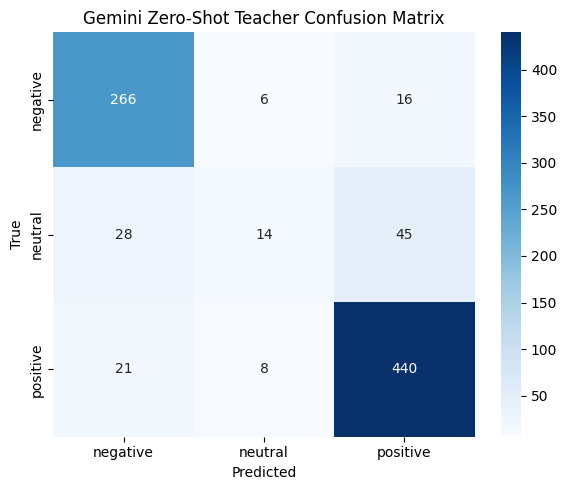


Total Errors: 124


,row_id,review,aspect,true_sentiment,predicted_sentiment
3,teacher_1051,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,positive
11,teacher_190,"Just like a typical analog course, started fro...",Prof. Levine,positive,neutral
17,teacher_2060,"I actually like Chem, so the first 2 exams wer...",textbook,neutral,positive
18,teacher_1727,"Very helpful, great teacher, doesn't take off ...",stupid points,positive,negative
38,teacher_2043,Ms. Gray is nice. Seems new to teaching. She d...,Class format,neutral,negative



Neutral Errors: 73


,row_id,review,aspect,true_sentiment,predicted_sentiment
3,teacher_1051,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,positive
17,teacher_2060,"I actually like Chem, so the first 2 exams wer...",textbook,neutral,positive
38,teacher_2043,Ms. Gray is nice. Seems new to teaching. She d...,Class format,neutral,negative
43,teacher_425,I am a first year biology student who took thi...,laboratory component,neutral,positive
48,teacher_2477,"He teaches okay, but totally screws you over o...",This professor,neutral,negative


In [59]:
# =====================================================
# TEACHER ZERO-SHOT METRICS
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# METRICS
# =====================================================

y_true = teacher_predictions[
    "true_sentiment"
]

y_pred = teacher_predictions[
    "predicted_sentiment"
]

teacher_zero_accuracy = accuracy_score(
    y_true,
    y_pred
)

teacher_zero_macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

teacher_zero_weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("=" * 50)
print("TEACHER ZERO-SHOT RESULTS")
print("=" * 50)

print("Accuracy     :", round(teacher_zero_accuracy, 4))
print("Macro F1     :", round(teacher_zero_macro_f1, 4))
print("Weighted F1  :", round(teacher_zero_weighted_f1, 4))

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

# =====================================================
# SAVE METRICS
# =====================================================

teacher_metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro_F1",
        "Weighted_F1"
    ],

    "Score": [
        teacher_zero_accuracy,
        teacher_zero_macro_f1,
        teacher_zero_weighted_f1
    ]
})

teacher_metrics_df.to_csv(
    "gemini_multidomain_zero_shot_teacher_metrics.csv",
    index=False
)

display(teacher_metrics_df)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "negative",
        "neutral",
        "positive"
    ],
    yticklabels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.title(
    "Gemini Zero-Shot Teacher Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()

plt.savefig(
    "gemini_multidomain_zero_shot_teacher_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# ERROR ANALYSIS
# =====================================================

teacher_errors = teacher_predictions[
    teacher_predictions["true_sentiment"]
    !=
    teacher_predictions["predicted_sentiment"]
]

print(
    "\nTotal Errors:",
    len(teacher_errors)
)

teacher_errors.to_csv(
    "gemini_multidomain_zero_shot_teacher_errors.csv",
    index=False
)

display(
    teacher_errors.head()
)

# =====================================================
# NEUTRAL ERROR ANALYSIS
# =====================================================

teacher_neutral_errors = teacher_predictions[
    teacher_predictions["true_sentiment"]
    == "neutral"
]

teacher_neutral_errors = teacher_neutral_errors[
    teacher_neutral_errors["predicted_sentiment"]
    != "neutral"
]

print(
    "\nNeutral Errors:",
    len(teacher_neutral_errors)
)

teacher_neutral_errors.to_csv(
    "gemini_multidomain_zero_shot_teacher_neutral_errors.csv",
    index=False
)

display(
    teacher_neutral_errors.head()
)

In [57]:
university_predictions = run_gemini_zero_shot(
    university_test,
    "gemini_multidomain_zero_shot_university"
)

print("University Zero-Shot Completed")

university_predictions.head()

 50%|█████     | 423/844 [24:10<25:50,  3.68s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...


 59%|█████▉    | 497/844 [28:21<17:04,  2.95s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...


 59%|█████▉    | 498/844 [28:33<32:46,  5.68s/it]

...

 99%|█████████▉| 836/844 [51:11<00:25,  3.20s/it]

Attempt 1/8 failed.
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 5 seconds...


100%|██████████| 844/844 [51:44<00:00,  3.68s/it]

University Zero-Shot Completed


,row_id,review,aspect,true_sentiment,predicted_sentiment
0,university_1004,Exeter University was my first choice and I do...,community,positive,positive
1,university_3270,"Nice university to study in, all the teachers ...",university,positive,positive
2,university_1143,I love the options for my course and the uni i...,options for my course,positive,positive
3,university_2061,It’s difficult for me to rate the aspects of t...,students union,neutral,positive
4,university_3278,Brilliant university. Home away from home.,university,positive,positive


UNIVERSITY ZERO-SHOT RESULTS
Accuracy     : 0.9514
Macro F1     : 0.7383
Weighted F1  : 0.9423

Classification Report

              precision    recall  f1-score   support

    negative       0.86      0.92      0.89       132
     neutral       0.73      0.22      0.34        36
    positive       0.97      1.00      0.98       676

    accuracy                           0.95       844
   macro avg       0.85      0.71      0.74       844
weighted avg       0.95      0.95      0.94       844


Metrics Saved Successfully


,Metric,Score
0,Accuracy,0.951422
1,Macro_F1,0.738264
2,Weighted_F1,0.942330


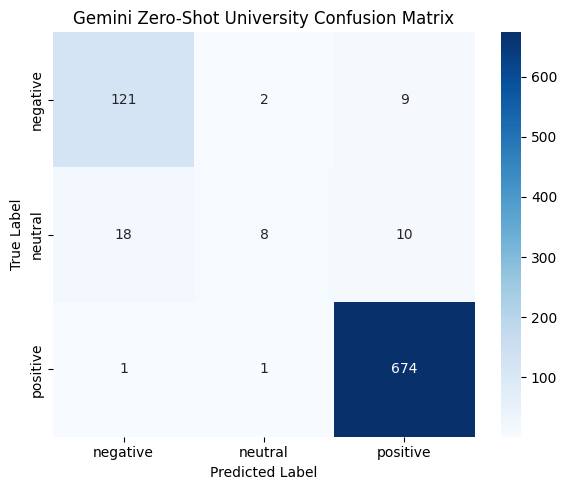


Total Errors: 41


,row_id,review,aspect,true_sentiment,predicted_sentiment
3,university_2061,It’s difficult for me to rate the aspects of t...,students union,neutral,positive
30,university_2606,"offers a lot of facilities, could improve it's...",internet connection,neutral,negative
37,university_355,"library is 24/7, The campus is beautiful and s...",food choices,neutral,negative
46,university_1816,I like this course for gaining basic calculus ...,assignments,negative,positive
124,university_2869,"The University's social side is thriving, many...",library,negative,positive



Neutral Errors: 28


,row_id,review,aspect,true_sentiment,predicted_sentiment
3,university_2061,It’s difficult for me to rate the aspects of t...,students union,neutral,positive
30,university_2606,"offers a lot of facilities, could improve it's...",internet connection,neutral,negative
37,university_355,"library is 24/7, The campus is beautiful and s...",food choices,neutral,negative
160,university_2636,Good overall. But should listen to wishes of t...,The Students Guild,neutral,negative
198,university_3558,ECE 140 is one of my favourite first-semester ...,circuits lab,neutral,positive



Classification Report Saved Successfully


In [58]:
# =====================================================
# UNIVERSITY ZERO-SHOT METRICS
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# METRICS
# =====================================================

y_true = university_predictions[
    "true_sentiment"
]

y_pred = university_predictions[
    "predicted_sentiment"
]

university_zero_accuracy = accuracy_score(
    y_true,
    y_pred
)

university_zero_macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

university_zero_weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("=" * 50)
print("UNIVERSITY ZERO-SHOT RESULTS")
print("=" * 50)

print(
    "Accuracy     :",
    round(university_zero_accuracy, 4)
)

print(
    "Macro F1     :",
    round(university_zero_macro_f1, 4)
)

print(
    "Weighted F1  :",
    round(university_zero_weighted_f1, 4)
)

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

# =====================================================
# SAVE METRICS
# =====================================================

university_metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro_F1",
        "Weighted_F1"
    ],

    "Score": [
        university_zero_accuracy,
        university_zero_macro_f1,
        university_zero_weighted_f1
    ]
})

university_metrics_df.to_csv(
    "gemini_multidomain_zero_shot_university_metrics.csv",
    index=False
)

print("\nMetrics Saved Successfully")

display(
    university_metrics_df
)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "negative",
        "neutral",
        "positive"
    ],
    yticklabels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.title(
    "Gemini Zero-Shot University Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.tight_layout()

plt.savefig(
    "gemini_multidomain_zero_shot_university_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# ERROR ANALYSIS
# =====================================================

university_errors = university_predictions[
    university_predictions["true_sentiment"]
    !=
    university_predictions["predicted_sentiment"]
]

print(
    "\nTotal Errors:",
    len(university_errors)
)

university_errors.to_csv(
    "gemini_multidomain_zero_shot_university_errors.csv",
    index=False
)

display(
    university_errors.head()
)

# =====================================================
# NEUTRAL ERROR ANALYSIS
# =====================================================

university_neutral_errors = university_predictions[
    university_predictions["true_sentiment"]
    == "neutral"
]

university_neutral_errors = university_neutral_errors[
    university_neutral_errors["predicted_sentiment"]
    != "neutral"
]

print(
    "\nNeutral Errors:",
    len(university_neutral_errors)
)

university_neutral_errors.to_csv(
    "gemini_multidomain_zero_shot_university_neutral_errors.csv",
    index=False
)

display(
    university_neutral_errors.head()
)

# =====================================================
# SAVE CLASSIFICATION REPORT
# =====================================================

report_dict = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_df.to_csv(
    "gemini_multidomain_zero_shot_university_classification_report.csv"
)

print(
    "\nClassification Report Saved Successfully"
)

In [63]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score
)

def calculate_metrics(prediction_file):

    df = pd.read_csv(prediction_file)

    y_true = df["true_sentiment"]
    y_pred = df["predicted_sentiment"]

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),
        "Weighted_F1": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

course_zero = calculate_metrics(
    "gemini_multidomain_zero_shot_course/predictions.csv"
)

teacher_zero = calculate_metrics(
    "gemini_multidomain_zero_shot_teacher/predictions.csv"
)

university_zero = calculate_metrics(
    "gemini_multidomain_zero_shot_university/predictions.csv"
)

course_few = calculate_metrics(
    "gemini_multidomain_few_shot_course/predictions.csv"
)

teacher_few = calculate_metrics(
    "gemini_multidomain_few_shot_teacher/predictions.csv"
)

university_few = calculate_metrics(
    "gemini_multidomain_few_shot_university/predictions.csv"
)

comparison_df = pd.DataFrame({

    "Domain": [
        "Course",
        "Teacher",
        "University"
    ],

    "Zero_Accuracy": [
        course_zero["Accuracy"],
        teacher_zero["Accuracy"],
        university_zero["Accuracy"]
    ],

    "Few_Accuracy": [
        course_few["Accuracy"],
        teacher_few["Accuracy"],
        university_few["Accuracy"]
    ],

    "Zero_Macro_F1": [
        course_zero["Macro_F1"],
        teacher_zero["Macro_F1"],
        university_zero["Macro_F1"]
    ],

    "Few_Macro_F1": [
        course_few["Macro_F1"],
        teacher_few["Macro_F1"],
        university_few["Macro_F1"]
    ],

    "Zero_Weighted_F1": [
        course_zero["Weighted_F1"],
        teacher_zero["Weighted_F1"],
        university_zero["Weighted_F1"]
    ],

    "Few_Weighted_F1": [
        course_few["Weighted_F1"],
        teacher_few["Weighted_F1"],
        university_few["Weighted_F1"]
    ]
})

comparison_df["Accuracy_Improvement"] = (
    comparison_df["Few_Accuracy"]
    - comparison_df["Zero_Accuracy"]
)

comparison_df["Macro_F1_Improvement"] = (
    comparison_df["Few_Macro_F1"]
    - comparison_df["Zero_Macro_F1"]
)

comparison_df["Weighted_F1_Improvement"] = (
    comparison_df["Few_Weighted_F1"]
    - comparison_df["Zero_Weighted_F1"]
)

display(
    comparison_df.round(4)
)

comparison_df.to_csv(
    "gemini_zero_shot_vs_few_shot_summary.csv",
    index=False
)

,Domain,Zero_Accuracy,Few_Accuracy,Zero_Macro_F1,Few_Macro_F1,Zero_Weighted_F1,Few_Weighted_F1,Accuracy_Improvement,Macro_F1_Improvement,Weighted_F1_Improvement
0,Course,0.7832,0.7950,0.6460,0.6895,0.7462,0.7718,0.0118,0.0435,0.0256
1,Teacher,0.8531,0.8531,0.6777,0.6996,0.8303,0.8376,0.0000,0.0220,0.0073
2,University,0.9514,0.9455,0.7383,0.7217,0.9423,0.9382,-0.0059,-0.0166,-0.0041


## Zero-Shot vs Few-Shot Prompting Comparison

To investigate the impact of prompt engineering on generative Aspect-Based Sentiment Analysis, Gemini 2.5 Flash was evaluated using both zero-shot and few-shot prompting strategies across the Course, Teacher, and University domains. Performance was measured using Accuracy, Macro F1-score, and Weighted F1-score.

### Overall Comparison

| Domain | Zero-Shot Accuracy | Few-Shot Accuracy | Zero-Shot Macro F1 | Few-Shot Macro F1 | Zero-Shot Weighted F1 | Few-Shot Weighted F1 |
|----------|----------|----------|----------|----------|----------|----------|
| Course | 0.7832 | 0.7950 | 0.6460 | 0.6895 | 0.7462 | 0.7718 |
| Teacher | 0.8531 | 0.8531 | 0.6777 | 0.6996 | 0.8303 | 0.8376 |
| University | 0.9514 | 0.9455 | 0.7383 | 0.7217 | 0.9423 | 0.9382 |

### Performance Improvements

| Domain | Accuracy Improvement | Macro F1 Improvement | Weighted F1 Improvement |
|----------|----------|----------|----------|
| Course | +0.0118 | +0.0435 | +0.0256 |
| Teacher | +0.0000 | +0.0220 | +0.0073 |
| University | -0.0059 | -0.0166 | -0.0041 |

### Course Domain

The Course domain benefited the most from few-shot prompting. Accuracy increased from **78.32%** to **79.50%**, while Macro F1 improved from **0.6460** to **0.6895**, representing the largest gain among all domains. The improvement was primarily driven by better recognition of neutral sentiment examples, which were frequently misclassified under the zero-shot setting. These results suggest that providing representative examples helped Gemini better distinguish subtle sentiment boundaries within course-related reviews.

### Teacher Domain

For the Teacher domain, few-shot prompting maintained the same overall accuracy (**85.31%**) while improving Macro F1 from **0.6777** to **0.6996**. Although the overall number of correctly classified instances remained unchanged, the increase in Macro F1 indicates improved performance on minority sentiment classes, particularly neutral sentiment. This demonstrates that few-shot prompting contributed to a more balanced classification performance across sentiment categories.

### University Domain

Unlike the Course and Teacher domains, the University domain experienced a slight decline in performance under few-shot prompting. Accuracy decreased from **95.14%** to **94.55%**, while Macro F1 fell from **0.7383** to **0.7217**. This behaviour may be attributed to the highly imbalanced sentiment distribution observed during exploratory data analysis, where approximately 80% of University instances expressed positive sentiment. Since Gemini already performed exceptionally well in the zero-shot setting, the addition of few-shot demonstrations may have introduced unnecessary bias or noise.

### Discussion

The results indicate that the effectiveness of few-shot prompting is domain dependent. Few-shot prompting provided meaningful improvements for the more complex Course and Teacher domains, which contain greater sentiment diversity and higher aspect variability. In contrast, the University domain exhibited limited benefit due to its highly positive sentiment distribution and already strong zero-shot performance.

Overall, the findings suggest that few-shot prompting is particularly valuable when the task involves nuanced sentiment distinctions and underrepresented classes. The largest improvements were observed in Macro F1-score, indicating enhanced performance across all sentiment categories rather than improvements driven solely by the majority class.

### Key Finding

Few-shot prompting improved Gemini's performance in the Course and Teacher domains, particularly for minority sentiment classes, resulting in higher Macro F1-scores and more balanced classification behaviour. However, for the University domain, where sentiment polarity was already highly predictable, zero-shot prompting remained the stronger approach. These findings demonstrate that the effectiveness of few-shot prompting depends on domain complexity and sentiment distribution rather than providing universal performance gains.

In [64]:
# =====================================================
# OVERALL MULTIDOMAIN GEMINI PERFORMANCE
# =====================================================

overall_results = pd.DataFrame()

overall_results["Domain"] = comparison_df["Domain"]

overall_results["Best_Setting"] = comparison_df.apply(
    lambda row:
        "Few-Shot"
        if row["Few_Macro_F1"] > row["Zero_Macro_F1"]
        else "Zero-Shot",
    axis=1
)

overall_results["Accuracy"] = comparison_df.apply(
    lambda row:
        row["Few_Accuracy"]
        if row["Few_Macro_F1"] > row["Zero_Macro_F1"]
        else row["Zero_Accuracy"],
    axis=1
)

overall_results["Macro_F1"] = comparison_df.apply(
    lambda row:
        row["Few_Macro_F1"]
        if row["Few_Macro_F1"] > row["Zero_Macro_F1"]
        else row["Zero_Macro_F1"],
    axis=1
)

overall_results["Weighted_F1"] = comparison_df.apply(
    lambda row:
        row["Few_Weighted_F1"]
        if row["Few_Macro_F1"] > row["Zero_Macro_F1"]
        else row["Zero_Weighted_F1"],
    axis=1
)

display(
    overall_results.round(4)
)

overall_results.to_csv(
    "gemini_overall_multidomain_results.csv",
    index=False
)

print("Overall Results Saved Successfully")

,Domain,Best_Setting,Accuracy,Macro_F1,Weighted_F1
0,Course,Few-Shot,0.7950,0.6895,0.7718
1,Teacher,Few-Shot,0.8531,0.6996,0.8376
2,University,Zero-Shot,0.9514,0.7383,0.9423


Overall Results Saved Successfully


In [65]:
# =====================================================
# OVERALL GEMINI SUMMARY
# =====================================================

overall_summary = pd.DataFrame({

    "Metric": [
        "Average Accuracy",
        "Average Macro F1",
        "Average Weighted F1"
    ],

    "Score": [

        overall_results["Accuracy"].mean(),

        overall_results["Macro_F1"].mean(),

        overall_results["Weighted_F1"].mean()

    ]

})

display(
    overall_summary.round(4)
)

overall_summary.to_csv(
    "gemini_overall_summary.csv",
    index=False
)

print("Overall Summary Saved Successfully")

,Metric,Score
0,Average Accuracy,0.8665
1,Average Macro F1,0.7091
2,Average Weighted F1,0.8506


Overall Summary Saved Successfully


In [73]:
# =====================================================
# VERIFY CROSS-DOMAIN FILES
# =====================================================

import pandas as pd

files = [
    "Course Few-Shot.csv",
    "Course Zero-Shot.csv",
    "Teacher Few-Shot.csv",
    "Teacher Zero-Shot.csv",
    "University Few-Shot.csv",
    "University Zero-Shot.csv"
]

for file in files:

    print("=" * 80)
    print(file)

    df = pd.read_csv(file)

    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())

    print("\nFirst 3 rows:")
    display(df.head(3))

Course Few-Shot.csv
Shape: (844, 3)
Columns: ['row_id', 'true_sentiment', 'predicted_sentiment']

First 3 rows:


,row_id,true_sentiment,predicted_sentiment
0,course_188,negative,negative
1,course_3409,negative,negative
2,course_254,negative,positive


Course Zero-Shot.csv
Shape: (844, 3)
Columns: ['row_id', 'true_sentiment', 'predicted_sentiment']

First 3 rows:


,row_id,true_sentiment,predicted_sentiment
0,course_188,negative,negative
1,course_3409,negative,negative
2,course_254,negative,positive


Teacher Few-Shot.csv
Shape: (844, 3)
Columns: ['row_id', 'true_sentiment', 'predicted_sentiment']

First 3 rows:


...

,row_id,true_sentiment,predicted_sentiment
0,teacher_3717,negative,negative
1,teacher_671,positive,positive
2,teacher_2314,positive,positive


University Few-Shot.csv
Shape: (844, 3)
Columns: ['row_id', 'true_sentiment', 'predicted_sentiment']

First 3 rows:


,row_id,true_sentiment,predicted_sentiment
0,university_1004,positive,positive
1,university_3270,positive,positive
2,university_1143,positive,positive


University Zero-Shot.csv
Shape: (844, 3)
Columns: ['row_id', 'true_sentiment', 'predicted_sentiment']

First 3 rows:


,row_id,true_sentiment,predicted_sentiment
0,university_1004,positive,positive
1,university_3270,positive,positive
2,university_1143,positive,positive


In [74]:
# =====================================================
# LOAD BEST MULTIDOMAIN AND CROSS-DOMAIN RESULTS
# =====================================================

import pandas as pd

# -------------------------
# MULTIDOMAIN (YOUR RESULTS)
# -------------------------

multi_course = pd.read_csv(
    "gemini_multidomain_few_shot_course/predictions.csv"
)

multi_teacher = pd.read_csv(
    "gemini_multidomain_few_shot_teacher/predictions.csv"
)

multi_university = pd.read_csv(
    "gemini_multidomain_zero_shot_university/predictions.csv"
)

# -------------------------
# CROSS-DOMAIN (PARTNER)
# -------------------------

cross_course = pd.read_csv(
    "Course Few-Shot.csv"
)

cross_teacher = pd.read_csv(
    "Teacher Few-Shot.csv"
)

cross_university = pd.read_csv(
    "University Zero-Shot.csv"
)

print("All files loaded successfully")

All files loaded successfully


In [75]:
# =====================================================
# MULTIDOMAIN vs CROSS-DOMAIN
# =====================================================

def compare_models(
    multidomain_df,
    crossdomain_df,
    domain_name
):

    merged = multidomain_df.merge(
        crossdomain_df,
        on="row_id",
        suffixes=(
            "_multi",
            "_cross"
        )
    )

    merged["multi_correct"] = (
        merged["true_sentiment_multi"]
        ==
        merged["predicted_sentiment_multi"]
    )

    merged["cross_correct"] = (
        merged["true_sentiment_cross"]
        ==
        merged["predicted_sentiment_cross"]
    )

    agreement_rate = (
        (
            merged["predicted_sentiment_multi"]
            ==
            merged["predicted_sentiment_cross"]
        )
        .mean()
        * 100
    )

    multi_wins = merged[
        (merged["multi_correct"])
        &
        (~merged["cross_correct"])
    ]

    cross_wins = merged[
        (~merged["multi_correct"])
        &
        (merged["cross_correct"])
    ]

    summary = {

        "Domain": domain_name,

        "Agreement_Rate": agreement_rate,

        "Disagreements":
        len(merged) -
        (
            merged[
                "predicted_sentiment_multi"
            ]
            ==
            merged[
                "predicted_sentiment_cross"
            ]
        ).sum(),

        "Multidomain_Wins":
        len(multi_wins),

        "Crossdomain_Wins":
        len(cross_wins)

    }

    return (
        merged,
        multi_wins,
        cross_wins,
        summary
    )

In [76]:
# =====================================================
# RUN COMPARISON
# =====================================================

course_results = compare_models(
    multi_course,
    cross_course,
    "Course"
)

teacher_results = compare_models(
    multi_teacher,
    cross_teacher,
    "Teacher"
)

university_results = compare_models(
    multi_university,
    cross_university,
    "University"
)

summary_df = pd.DataFrame([

    course_results[3],

    teacher_results[3],

    university_results[3]

])

display(
    summary_df.round(2)
)

summary_df.to_csv(
    "gemini_multidomain_vs_crossdomain_summary.csv",
    index=False
)

,Domain,Agreement_Rate,Disagreements,Multidomain_Wins,Crossdomain_Wins
0,Course,91.94,68,31,23
1,Teacher,95.38,39,12,20
2,University,98.34,14,5,6


In [77]:
# =====================================================
# OVERALL WINNER ANALYSIS
# =====================================================

total_multi_wins = summary_df[
    "Multidomain_Wins"
].sum()

total_cross_wins = summary_df[
    "Crossdomain_Wins"
].sum()

overall_winner_df = pd.DataFrame({

    "Model": [
        "Multidomain Gemini",
        "Cross-Domain Gemini"
    ],

    "Wins": [
        total_multi_wins,
        total_cross_wins
    ]

})

display(overall_winner_df)

overall_winner_df.to_csv(
    "gemini_overall_winner_analysis.csv",
    index=False
)

print(
    f"Multidomain Wins: {total_multi_wins}"
)

print(
    f"Cross-Domain Wins: {total_cross_wins}"
)

,Model,Wins
0,Multidomain Gemini,48
1,Cross-Domain Gemini,49


Multidomain Wins: 48
Cross-Domain Wins: 49


## Multidomain vs Cross-Domain Gemini Comparison

To evaluate the impact of domain configuration on generative Aspect-Based Sentiment Analysis, the best-performing multidomain Gemini models were compared against the corresponding best-performing cross-domain Gemini models using row-level prediction analysis. Predictions were matched using the shared `row_id` field, enabling direct comparison of individual classifications across both approaches.

### Agreement Analysis

| Domain | Agreement Rate (%) | Disagreements |
|----------|----------:|----------:|
| Course | 91.94 | 68 |
| Teacher | 95.38 | 39 |
| University | 98.34 | 14 |

The agreement rates were consistently high across all domains, ranging from 91.94% to 98.34%. This indicates that multidomain and cross-domain Gemini models produced highly similar predictions for the majority of test instances.

### Winner Analysis

| Domain | Multidomain Wins | Cross-Domain Wins |
|----------|----------:|----------:|
| Course | 31 | 23 |
| Teacher | 12 | 20 |
| University | 5 | 6 |

The Course domain was the only domain where the multidomain Gemini model achieved more wins than the cross-domain model. In contrast, the cross-domain model obtained slightly more wins in the Teacher and University domains.

### Overall Winner Analysis

| Model | Total Wins |
|----------|----------:|
| Multidomain Gemini | 48 |
| Cross-Domain Gemini | 49 |

The overall winner analysis revealed an almost identical performance profile between the two approaches. Across all disagreement cases, the multidomain model achieved 48 wins, while the cross-domain model achieved 49 wins.

### Discussion

The results suggest that Gemini exhibits strong robustness to domain configuration. Unlike encoder-based models such as ModernBERT, BERTweet, and LLaMA, which often displayed noticeable performance differences between multidomain and cross-domain training, Gemini produced highly consistent predictions regardless of the domain setup.

The exceptionally high agreement rates indicate that Gemini's large-scale pretraining enables effective generalization across educational review domains. While multidomain prompting provided a modest advantage for the Course domain, the cross-domain approach performed slightly better for the Teacher and University domains. However, the overall difference between the two approaches was negligible.

### Key Finding

The winner analysis demonstrated near-identical performance between multidomain and cross-domain Gemini prompting, with only a single prediction separating the two approaches across 2,532 test instances. These findings indicate that Gemini's performance is largely independent of domain configuration, highlighting the strong generalization capabilities of modern generative language models for Aspect-Based Sentiment Analysis.